In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats
from scipy.integrate import trapezoid

def format_title(title:str) -> None:
    print("-"*80)
    print(title)
    print("-"*80)

In [14]:
# ============================================================
# 0. Load data
# ============================================================

PATH = Path("../data/ranks_crowdcent.csv")
df = pd.read_csv(PATH)
df["release_date"] = pd.to_datetime(df["release_date"])

score_cols = ["pred_10d", "pred_30d"]

In [15]:
# ============================================================
# 1. Basic dataset structure
# ============================================================

format_title("Dataset structure")

print(f"Rows: {len(df):,}")
print(f"Columns: {list(df.columns)}")
print(f"Dates: {df['release_date'].nunique():,}")
print(f"Date range: {df['release_date'].min().date()} → {df['release_date'].max().date()}")

assets_per_day = df.groupby("release_date")["id"].nunique()

print("\nAssets per date:")
print(assets_per_day.describe().to_string())

--------------------------------------------------------------------------------
Dataset structure
--------------------------------------------------------------------------------
Rows: 59,682
Columns: ['id', 'pred_10d', 'pred_30d', 'release_date']
Dates: 337
Date range: 2025-06-05 → 2026-05-07

Assets per date:
count    337.000000
mean     177.097923
std        6.496283
min      167.000000
25%      170.000000
50%      177.000000
75%      185.000000
max      186.000000


In [ ]:
# ============================================================
# 2. Moment statistics: mean, std, skew, kurtosis
# ============================================================

moment_rows = []

for col in score_cols:
    x = df[col].dropna().astype(float)

    moment_rows.append({
        "horizon": col,
        "n": len(x),
        "mean": x.mean(),
        "std": x.std(ddof=1),
        "skew": x.skew(),
        "excess_kurtosis": x.kurt(),
        "pearson_kurtosis": x.kurt() + 3,
        "min": x.min(),
        "max": x.max(),
    })

moments = pd.DataFrame(moment_rows)

format_title("Moments")
print(moments.to_string(index=False))


--------------------------------------------------------------------------------
Moments
--------------------------------------------------------------------------------
 horizon     n     mean      std     skew  excess_kurtosis  pearson_kurtosis      min  max
pred_10d 59682 0.502823 0.189859 0.041002        -0.708382          2.291618 0.005917  1.0
pred_30d 59682 0.502823 0.193456 0.062066        -0.728533          2.271467 0.005917  1.0


In [17]:
# ============================================================
# 3. Uniformity diagnostics
# ============================================================

uniform_rows = []

for col in score_cols:
    x = df[col].dropna().astype(float).to_numpy()

    ks_uniform = stats.kstest(x, "uniform", args=(0, 1))

    # Decile chi-square test against uniform deciles
    counts, _ = np.histogram(x, bins=np.linspace(0, 1, 11))
    expected = np.full_like(counts, fill_value=len(x) / 10, dtype=float)
    chi2_stat, chi2_pvalue = stats.chisquare(counts, expected)

    uniform_rows.append({
        "horizon": col,
        "KS_uniform_stat": ks_uniform.statistic,
        "KS_uniform_pvalue": ks_uniform.pvalue,
        "chi2_decile_stat": chi2_stat,
        "chi2_decile_pvalue": chi2_pvalue,
    })

uniform_tests = pd.DataFrame(uniform_rows)

format_title("Uniformity tests")
print(uniform_tests.to_string(index=False))



--------------------------------------------------------------------------------
Uniformity tests
--------------------------------------------------------------------------------
 horizon  KS_uniform_stat  KS_uniform_pvalue  chi2_decile_stat  chi2_decile_pvalue
pred_10d         0.151942                0.0      24331.627559                 0.0
pred_30d         0.147094                0.0      22796.035254                 0.0


In [18]:

# ============================================================
# 4. Daily tail counts
# ============================================================

tail_rows = []

for col in score_cols:
    tmp = df.copy()
    tmp["below_010"] = tmp[col] < 0.15
    tmp["above_090"] = tmp[col] > 0.85
    tmp["extreme_010_090"] = tmp["below_010"] | tmp["above_090"]

    daily = (
        tmp.groupby("release_date")
           .agg(
               n_assets=("id", "nunique"),
               n_below_010=("below_010", "sum"),
               n_above_090=("above_090", "sum"),
               n_extreme_010_090=("extreme_010_090", "sum"),
           )
    )

    daily["share_extreme_010_090"] = daily["n_extreme_010_090"] / daily["n_assets"]

    tail_rows.append({
        "horizon": col,
        "avg_assets_per_day": daily["n_assets"].mean(),
        "avg_below_010": daily["n_below_010"].mean(),
        "avg_above_090": daily["n_above_090"].mean(),
        "avg_extreme_010_090": daily["n_extreme_010_090"].mean(),
        "median_extreme_010_090": daily["n_extreme_010_090"].median(),
        "avg_share_extreme_010_090": daily["share_extreme_010_090"].mean(),
    })

tail_summary = pd.DataFrame(tail_rows)

format_title("Daily tail counts")
print(tail_summary.to_string(index=False))

--------------------------------------------------------------------------------
Daily tail counts
--------------------------------------------------------------------------------
 horizon  avg_assets_per_day  avg_below_010  avg_above_090  avg_extreme_010_090  median_extreme_010_090  avg_share_extreme_010_090
pred_10d          177.097923       3.857567       5.189911             9.047478                     8.0                   0.051039
pred_30d          177.097923       3.922849       6.080119            10.002967                     9.0                   0.056267


In [19]:
# ============================================================
# 5. Beta distribution fitting
# ============================================================

beta_rows = []

for col in score_cols:
    x = df[col].dropna().astype(float).to_numpy()

    # Method-of-moments Beta fit on [0, 1]
    mean = x.mean()
    var = x.var(ddof=1)

    common = mean * (1 - mean) / var - 1
    alpha_mom = mean * common
    beta_mom = (1 - mean) * common

    # MLE Beta fit on fixed support [0, 1]
    # Clip exact endpoints to avoid infinite likelihood issues.
    eps = 1e-9
    x_clip = np.clip(x, eps, 1 - eps)

    alpha_mle, beta_mle, loc_mle, scale_mle = stats.beta.fit(
        x_clip,
        floc=0,
        fscale=1,
    )

    ks_beta = stats.kstest(
        x_clip,
        "beta",
        args=(alpha_mle, beta_mle, 0, 1),
    )

    beta_rows.append({
        "horizon": col,

        "beta_alpha_mom": alpha_mom,
        "beta_beta_mom": beta_mom,

        "beta_alpha_mle": alpha_mle,
        "beta_beta_mle": beta_mle,

        "KS_beta_stat": ks_beta.statistic,
        "KS_beta_pvalue": ks_beta.pvalue,
    })

beta_fits = pd.DataFrame(beta_rows)

format_title("Beta distribution fits")
print(beta_fits.to_string(index=False))


--------------------------------------------------------------------------------
Beta distribution fits
--------------------------------------------------------------------------------
 horizon  beta_alpha_mom  beta_beta_mom  beta_alpha_mle  beta_beta_mle  KS_beta_stat  KS_beta_pvalue
pred_10d        2.984389       2.950875        2.982504       2.937402      0.010012    1.264744e-05
pred_30d        2.855913       2.823842        2.855957       2.807481      0.012984    3.606551e-09


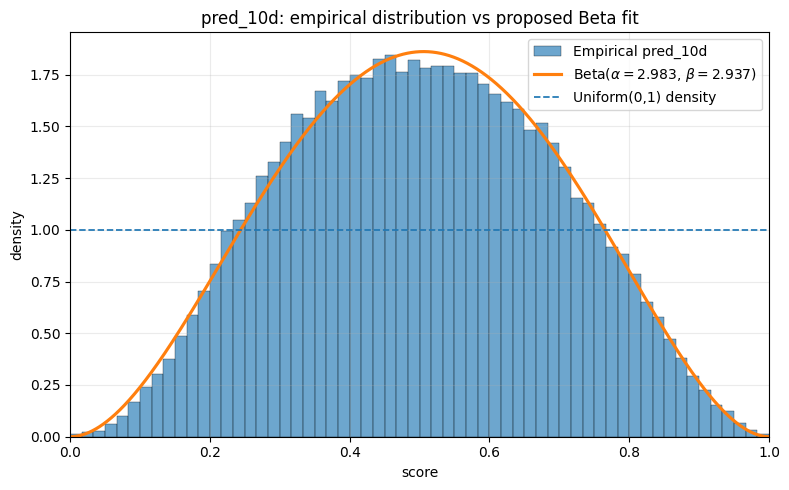

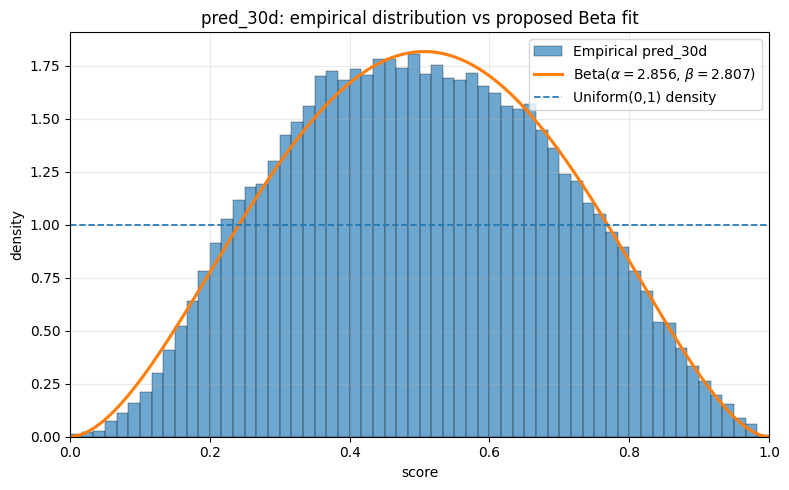

--------------------------------------------------------------------------------
Empirical vs Beta overlaps
--------------------------------------------------------------------------------
 horizon  proposed_alpha  proposed_beta  histogram_overlap_with_beta  kde_overlap_with_beta
pred_10d           2.983          2.937                     0.980936               0.983870
pred_30d           2.856          2.807                     0.976377               0.978657


In [20]:
# ============================================================
# 6. Compare empirical distribution with proposed Beta fits
# ============================================================

# Parameters previously proposed:
proposed_beta_params = {
    "pred_10d": (2.983, 2.937),
    "pred_30d": (2.856, 2.807),
}

grid = np.linspace(0, 1, 2001)
bins = np.linspace(0, 1, 61)

overlap_rows = []

for col in score_cols:
    x = df[col].dropna().astype(float).to_numpy()

    alpha, beta = proposed_beta_params[col]

    # Histogram density on 60 bins
    hist_density, bin_edges = np.histogram(x, bins=bins, density=True)
    bin_midpoints = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # Beta density evaluated at bin midpoints
    beta_density_mid = stats.beta.pdf(bin_midpoints, alpha, beta)

    # Approximate overlap coefficient:
    # integral min(empirical density, beta density) dx
    overlap_hist = np.sum(
        np.minimum(hist_density, beta_density_mid) * np.diff(bin_edges)
    )

    # Also compare via KDE for smoother empirical density
    kde = stats.gaussian_kde(x)
    empirical_kde_density = kde(grid)
    beta_density_grid = stats.beta.pdf(grid, alpha, beta)

    overlap_kde = trapezoid(
        np.minimum(empirical_kde_density, beta_density_grid),
        grid,
    )

    overlap_rows.append({
        "horizon": col,
        "proposed_alpha": alpha,
        "proposed_beta": beta,
        "histogram_overlap_with_beta": overlap_hist,
        "kde_overlap_with_beta": overlap_kde,
    })

    # --------------------------------------------------------
    # Plot: empirical histogram + proposed Beta PDF
    # --------------------------------------------------------

    fig, ax = plt.subplots(figsize=(8, 5))

    ax.hist(
        x,
        bins=bins,
        density=True,
        alpha=0.65,
        edgecolor="black",
        linewidth=0.35,
        label=f"Empirical {col}",
    )

    ax.plot(
        grid,
        beta_density_grid,
        linewidth=2.25,
        label=fr"Beta($\alpha={alpha:.3f}$, $\beta={beta:.3f}$)",
    )

    ax.axhline(
        1.0,
        linestyle="--",
        linewidth=1.25,
        label="Uniform(0,1) density",
    )

    ax.set_title(f"{col}: empirical distribution vs proposed Beta fit")
    ax.set_xlabel("score")
    ax.set_ylabel("density")
    ax.set_xlim(0, 1)
    ax.grid(True, alpha=0.25)
    ax.legend()

    fig.tight_layout()
    plt.show()


overlaps = pd.DataFrame(overlap_rows)

format_title("Empirical vs Beta overlaps")
print(overlaps.to_string(index=False))



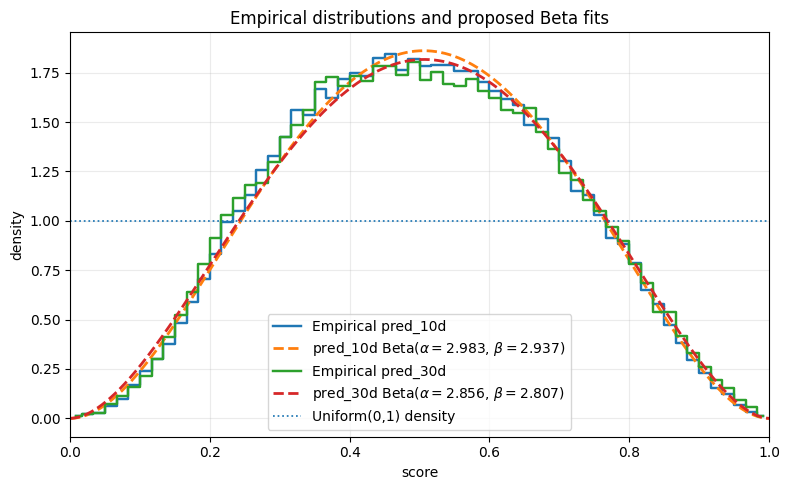

In [21]:
# ============================================================
# 7. Combined comparison plot
# ============================================================

fig, ax = plt.subplots(figsize=(8, 5))

for col in score_cols:
    x = df[col].dropna().astype(float).to_numpy()
    alpha, beta = proposed_beta_params[col]

    hist_density, bin_edges = np.histogram(x, bins=bins, density=True)
    bin_midpoints = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    ax.step(
        bin_midpoints,
        hist_density,
        where="mid",
        linewidth=1.75,
        label=f"Empirical {col}",
    )

    ax.plot(
        grid,
        stats.beta.pdf(grid, alpha, beta),
        linewidth=2.0,
        linestyle="--",
        label=fr"{col} Beta($\alpha={alpha:.3f}$, $\beta={beta:.3f}$)",
    )

ax.axhline(
    1.0,
    linestyle=":",
    linewidth=1.25,
    label="Uniform(0,1) density",
)

ax.set_title("Empirical distributions and proposed Beta fits")
ax.set_xlabel("score")
ax.set_ylabel("density")
ax.set_xlim(0, 1)
ax.grid(True, alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()

In [22]:
# ============================================================
# 8. Final compact conclusion
# ============================================================

format_title("Compact conclusion")

for col in score_cols:
    m = moments.loc[moments["horizon"] == col].iloc[0]
    b = beta_fits.loc[beta_fits["horizon"] == col].iloc[0]
    o = overlaps.loc[overlaps["horizon"] == col].iloc[0]

    print(f"\n{col}")
    print(f"  mean              = {m['mean']:.6f}")
    print(f"  std               = {m['std']:.6f}")
    print(f"  skew              = {m['skew']:.6f}")
    print(f"  excess kurtosis   = {m['excess_kurtosis']:.6f}")
    print(f"  MLE Beta alpha    = {b['beta_alpha_mle']:.6f}")
    print(f"  MLE Beta beta     = {b['beta_beta_mle']:.6f}")
    print(f"  KS vs uniform     = {uniform_tests.loc[uniform_tests['horizon'] == col, 'KS_uniform_stat'].iloc[0]:.6f}")
    print(f"  KS vs Beta        = {b['KS_beta_stat']:.6f}")
    print(f"  hist overlap Beta = {o['histogram_overlap_with_beta']:.6f}")
    print(f"  KDE overlap Beta  = {o['kde_overlap_with_beta']:.6f}")

--------------------------------------------------------------------------------
Compact conclusion
--------------------------------------------------------------------------------

pred_10d
  mean              = 0.502823
  std               = 0.189859
  skew              = 0.041002
  excess kurtosis   = -0.708382
  MLE Beta alpha    = 2.982504
  MLE Beta beta     = 2.937402
  KS vs uniform     = 0.151942
  KS vs Beta        = 0.010012
  hist overlap Beta = 0.980936
  KDE overlap Beta  = 0.983870

pred_30d
  mean              = 0.502823
  std               = 0.193456
  skew              = 0.062066
  excess kurtosis   = -0.728533
  MLE Beta alpha    = 2.855957
  MLE Beta beta     = 2.807481
  KS vs uniform     = 0.147094
  KS vs Beta        = 0.012984
  hist overlap Beta = 0.976377
  KDE overlap Beta  = 0.978657
